In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**Topology discovery plots**

Experiment 1: 
Cost and trace cost for varying GPS and encoder noise

In [3]:
df = pd.read_csv("topo_results/results_topology_discovery_123.csv")
df = df[np.isfinite(df["cost_per_obs"])]  # safety filter

# Normalise by total samples per subplot cell (both classes share same denominator)
df["weight"] = 1.0 / df.groupby(["sigma_pos", "sigma_theta", "sigma_encoder", "k"])["cost_per_obs"].transform("size")

encoder_vals = sorted(df["sigma_encoder"].unique())          # columns (x-axis)
pos_theta_vals = sorted(df.groupby(["sigma_pos","sigma_theta"]).groups)  # rows (y-axis)
k_vals = sorted(df["k"].unique()) 

for k, df_k in df.groupby("k"):
    
    fig, axes = plt.subplots(
        len(pos_theta_vals), 
        len(encoder_vals),
        figsize=(4 * len(encoder_vals), 3.5 * len(pos_theta_vals)),
        sharey=False
    )
    axes = np.atleast_2d(axes)  # Safe grid indexing for 1x1 or 1xN shapes

    palette = {True: "#1f77b4", False: "#ff7f0e"}

    for r, (sp, st) in enumerate(pos_theta_vals):
        for c, se in enumerate(encoder_vals):
            ax = axes[r, c]
            
            # Fast filter on the pre-sliced df_k
            sub = df_k[
                (df_k["sigma_pos"] == sp) & 
                (df_k["sigma_theta"] == st) & 
                (df_k["sigma_encoder"] == se)
            ]

            if sub.empty:
                ax.set_visible(False)
                continue

            sns.histplot(
                data=sub, 
                x="cost_per_obs", 
                hue="connected",
                weights="weight", 
                bins=100, 
                ax=ax,
                element="step", 
                fill=True, 
                alpha=0.4,
                palette=palette, 
                legend=(r == 0 and c == 0)
            )

            if r == 0:
                ax.set_title(f"sigma_enc = {se}", fontsize=10)
            ax.set_ylabel(f"sigma_pos={sp}, sigma_θ={st}\nproportion" if c == 0 else "")
            ax.set_xlabel("cost_per_obs" if r == len(pos_theta_vals) - 1 else "")

    # Include k in title and filename
    fig.suptitle(f"cost_per_obs distribution — k = {k} (connected vs not connected)", y=1.01)
    plt.tight_layout()
    plt.savefig(f"topo_results/figs/topology_cost_grid_k_{k}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)  # Prevents memory accumulation when generating multiple figures

In [4]:
df = pd.read_csv("topo_results/results_topology_discovery_123.csv")
df = df[np.isfinite(df["cost_per_obs"])]  # safety filter

encoder_vals = sorted(df["sigma_encoder"].unique())  # columns (x-axis)
pos_theta_vals = sorted(
    df.groupby(["sigma_pos", "sigma_theta"]).groups
)  # rows (y-axis)
k_vals = sorted(df["k"].unique())

threshold = (
    20.0  # Decision threshold separating connected (<20) and non-connected (>=20)
)

for k, df_k in df.groupby("k"):
  acc_matrix = np.zeros((len(pos_theta_vals), len(encoder_vals)))
  fpr_matrix = np.zeros((len(pos_theta_vals), len(encoder_vals)))
  annot_matrix = np.empty(
      (len(pos_theta_vals), len(encoder_vals)), dtype=object
  )

  for r, (sp, st) in enumerate(pos_theta_vals):
    for c, se in enumerate(encoder_vals):
      sub = df_k[
          (df_k["sigma_pos"] == sp)
          & (df_k["sigma_theta"] == st)
          & (df_k["sigma_encoder"] == se)
      ]

      if sub.empty:
        acc_matrix[r, c] = np.nan
        fpr_matrix[r, c] = np.nan
        annot_matrix[r, c] = "N/A"
        continue

      # Binary classification: Cost >= threshold -> Non-connected (Positive)
      pred_non_conn = sub["cost_per_obs"] >= threshold
      actual_non_conn = ~sub["connected"]

      TP = np.sum(pred_non_conn & actual_non_conn)
      TN = np.sum(~pred_non_conn & ~sub["connected"])
      FP = np.sum(pred_non_conn & ~sub["connected"])
      FN = np.sum(~pred_non_conn & actual_non_conn)

      total = len(sub)
      accuracy = (TP + TN) / total if total > 0 else 0.0
      actual_negatives = FP + TN
      fpr = FP / actual_negatives if actual_negatives > 0 else 0.0

      acc_matrix[r, c] = accuracy * 100
      fpr_matrix[r, c] = fpr * 100
      annot_matrix[r, c] = f"{accuracy*100:.1f}%\n(FPR: {fpr*100:.1f}%)"

  fig, ax = plt.subplots(
      figsize=(len(encoder_vals) * 1.8, len(pos_theta_vals) * 1.2 + 1)
  )

  row_labels = [f"pos={sp}, θ={st}" for sp, st in pos_theta_vals]
  col_labels = [str(se) for se in encoder_vals]

  sns.heatmap(
      acc_matrix,
      annot=annot_matrix,
      fmt="",
      cmap="Blues",
      vmin=0,
      vmax=100,
      cbar_kws={"label": "Accuracy (%)"},
      xticklabels=col_labels,
      yticklabels=row_labels,
      ax=ax,
      linewidths=0.5,
      linecolor="gray",
  )

  ax.set_title(
      f"Classification Performance Heatmap — k = {k}\n(Threshold ="
      f" {threshold})",
      fontsize=12,
      pad=15,
  )
  ax.set_xlabel("sigma_encoder", fontsize=10)
  ax.set_ylabel("sigma_pos, sigma_theta", fontsize=10)
  plt.xticks(rotation=0)
  plt.yticks(rotation=0)

  plt.tight_layout()
  plt.savefig(
      f"topo_results/figs/topology_heatmap_k_{k}.png", dpi=150, bbox_inches="tight"
  )
  plt.close(fig)

In [36]:
df = pd.read_csv("topo_results/results_topology_discovery_123.csv")
df = df[np.isfinite(df["cost_per_obs"])]  # safety filter

encoder_vals = sorted(df["sigma_encoder"].unique())  # x-axis (columns)
pos_theta_vals = sorted(
    df.groupby(["sigma_pos", "sigma_theta"]).groups
)  # y-axis (rows)
k_vals = sorted(df["k"].unique())

threshold = 5.0  # Cost threshold boundary separating classes
palette = {True: "#1f77b4", False: "#ff7f0e"}  # Connected vs Non-connected

for k, df_k in df.groupby("k"):
  fig, axes = plt.subplots(
      len(pos_theta_vals),
      len(encoder_vals),
      figsize=(3.5 * len(encoder_vals), 2.5 * len(pos_theta_vals)),
      sharex=True,
      sharey=True,
  )
  axes = np.atleast_2d(axes)

  for r, (sp, st) in enumerate(pos_theta_vals):
    for c, se in enumerate(encoder_vals):
      ax = axes[r, c]

      sub = df_k[
          (df_k["sigma_pos"] == sp)
          & (df_k["sigma_theta"] == st)
          & (df_k["sigma_encoder"] == se)
      ]

      if sub.empty:
        ax.set_visible(False)
        continue

      # Boolean masks for actual classes
      actual_conn = sub["connected"]  # True for Connected
      actual_non_conn = ~sub["connected"]  # True for Non-Connected

      # Boolean masks for predictions based on cost threshold
      pred_non_conn = sub["cost_per_obs"] >= threshold  # Predicted Non-Connected
      pred_conn = sub["cost_per_obs"] < threshold  # Predicted Connected

      # Confusion Matrix components
      TN = np.sum(pred_non_conn & actual_non_conn)  # Predicted Non-Conn & Actual Non-Conn
      TP = np.sum(pred_conn & actual_conn)  # Predicted Conn & Actual Conn
      FN = np.sum(
            pred_non_conn & actual_conn
      )  # Predicted Non-Conn & Actual Conn (Boundary Breach)
      FP = np.sum(
            pred_conn & actual_non_conn
      )  # Predicted Conn & Actual Non-Conn

      total = len(sub)
      accuracy = (TP + TN) / total * 100 if total > 0 else 0.0

      # FPR = FP / Actual Negatives (Actual Connected class)
      actual_connected_count = FP + TN
      fpr = FP / actual_connected_count * 100 if actual_connected_count > 0 else 0.0

      # Jittered strip plot on log-scale cost
      sns.stripplot(
          data=sub,
          x="connected",
          y="cost_per_obs",
          hue="connected",
          palette=palette,
          ax=ax,
          jitter=0.25,
          alpha=0.6,
          size=4,
          order=[True, False],
          legend=False,
      )

      ax.set_yscale("log")  # Preserves 2-3 order of magnitude gap visibility

      # Threshold decision boundary line
      thresh_line = ax.axhline(
          threshold, color="red", linestyle="--", linewidth=1.2
      )

      # Metric annotation box inside each cell
      ax.text(
          0.5,
          0.92,
          f"Acc: {accuracy:.1f}%\nFPR: {fpr:.1f}%",
          transform=ax.transAxes,
          fontsize=12,
          ha="right",
          va="top",
          bbox=dict(
              boxstyle="round,pad=0.3",
              facecolor="white",
              alpha=0.85,
              edgecolor="lightgray",
          ),
      )

      # Labeling and axis adjustments
      if r == 0:
        ax.set_title(f"sigma_enc = {se}", fontsize=12)

      if c == 0:
        ax.set_ylabel(f"pos={sp}, θ={st}\nCost (Log Scale)", fontsize=10)
      else:
        ax.set_ylabel("")

      if r == len(pos_theta_vals) - 1:
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Conn", "Non-Conn"], fontsize=12)
        ax.set_xlabel("Class", fontsize=12)
      else:
        ax.set_xlabel("")

  fig.suptitle(
      f"Cost Separation Distribution Grid — k = {k} (Threshold = {threshold})",
      y=1.01,
      fontsize=12,
  )

  plt.tight_layout()
  plt.savefig(
      f"topo_results/figs/exp1/topology_distribution_grid_k_{k}.png",
      dpi=150,
      bbox_inches="tight",
  )
  plt.close(fig)

In [ ]:
# 1. Filter and get top 10 per group
result = (
    df[df["connected"] == False]
    .sort_values("cost_per_obs")
    .groupby(["sigma_pos", "sigma_theta", "sigma_encoder"], as_index=False)
    .head(10)
)

# 2. Iterate and print
cols = ["sigma_pos", "sigma_theta", "sigma_encoder", "limb_id", "child_id", "cost_per_obs"]

for group_key, group_df in result.groupby(["sigma_pos", "sigma_theta", "sigma_encoder"]):
    print(f"\n=== Group Key: {group_key} ===")
    print(group_df[cols].to_string(index=False))

Experiment 2: how does noise effect calibration accuracy, euclidean error

In [10]:
df = pd.read_csv("topo_results/results_topology_discovery_123.csv")
df = df[np.isfinite(df["cost_per_obs"])].copy()  # safety filter

# 1. Define connected pairs and lookup table for true calibration positions
connected_pairs = [(0, 1), (1, 2), (3, 4), (4, 5), (6, 7), (7, 8)]
true_coords = [
    (-0.02, 0.0),
    (0.0, -0.01),
    (-0.02, 0.0),
    (0.0, -0.01),
    (-0.02, 0.0),
    (0.0, -0.01),
]

lookup_df = pd.DataFrame([
    {"limb_id": lid, "child_id": cid, "tru_cj_x": tx, "tru_cj_y": ty}
    for (lid, cid), (tx, ty) in zip(connected_pairs, true_coords)
])

# 2. Filter to connected pairs only & merge ground-truth positions
df_conn = df.merge(lookup_df, on=["limb_id", "child_id"], how="inner")

# 3. Compute Euclidean Joint Position Error
df_conn["euclidean_error"] = np.sqrt(
    (df_conn["cj_x"] - df_conn["tru_cj_x"]) ** 2
    + (df_conn["cj_y"] - df_conn["tru_cj_y"]) ** 2
)

# Format explicit label string for y-axis grouping
df_conn["pos_theta_label"] = (
    "pos="
    + df_conn["sigma_pos"].astype(str)
    + ", θ="
    + df_conn["sigma_theta"].astype(str)
)

# 4. Generate Heatmap Grid per k using Pandas Pivot Tables
for k, df_k in df_conn.groupby("k"):

  # Pivot table for Mean Euclidean Error
  pivot_mean = df_k.pivot_table(
      index="pos_theta_label",
      columns="sigma_encoder",
      values="euclidean_error",
      aggfunc="mean",
  )

  # Pivot table for Standard Deviation
  pivot_std = df_k.pivot_table(
      index="pos_theta_label",
      columns="sigma_encoder",
      values="euclidean_error",
      aggfunc="std",
  ).reindex_like(pivot_mean)

  # Vectorized multiline string formatting: mean (±std)
  annot_matrix = np.vectorize(
      lambda m, s: f"{m:.4f}\n(±{s:.4f})" if np.isfinite(m) else "N/A"
  )(pivot_mean.values, pivot_std.values)

  # Plot Setup
  fig, ax = plt.subplots(figsize=(8, 6))

  sns.heatmap(
      pivot_mean,
      annot=annot_matrix,
      fmt="",
      cmap="YlOrRd",
      cbar_kws={"label": "Mean Euclidean Error"},
      ax=ax,
      linewidths=0.5,
      linecolor="gray",
  )

  ax.set_title(
      f"Calibration Joint Error Heatmap — k = {k}\n(Connected Pairs Only)",
      fontsize=12,
      pad=15,
  )
  ax.set_xlabel("sigma_encoder", fontsize=10)
  ax.set_ylabel("sigma_pos, sigma_theta", fontsize=10)
  plt.xticks(rotation=0)
  plt.yticks(rotation=0)

  plt.tight_layout()
  plt.savefig(
      f"topo_results/figs/exp2/calibration_error_heatmap_k_{k}.png",
      dpi=150,
      bbox_inches="tight",
  )
  plt.close(fig)

Experiment 3: how number cost varies with number of observations and noise levels low, medium, high

In [15]:
df = pd.read_csv("topo_results/results_topology_discovery_123.csv")
df = df[np.isfinite(df["cost_per_obs"])].copy()

# 1. Map Low, Medium, High noise levels dynamically
pos_vals = sorted(df["sigma_pos"].unique())
theta_vals = sorted(df["sigma_theta"].unique())
enc_vals = sorted(df["sigma_encoder"].unique())

noise_configs = {
    "Low": (pos_vals[0], theta_vals[0], enc_vals[0]),
    "Medium": (
        pos_vals[len(pos_vals) // 2],
        theta_vals[len(theta_vals) // 2],
        enc_vals[len(enc_vals) // 2],
    ),
    "High": (pos_vals[-1], theta_vals[-1], enc_vals[-1]),
}

df_filtered_list = []
for label, (sp, st, se) in noise_configs.items():
  sub = df[
      (df["sigma_pos"] == sp)
      & (df["sigma_theta"] == st)
      & (df["sigma_encoder"] == se)
  ].copy()
  sub["noise_level"] = label
  df_filtered_list.append(sub)

df_noise = pd.concat(df_filtered_list, ignore_index=True)
df_noise["noise_level"] = pd.Categorical(
    df_noise["noise_level"], categories=["Low", "Medium", "High"], ordered=True
)
df_noise["class_label"] = df_noise["connected"].map(
    {True: "Connected Pairs", False: "Non-Connected Pairs"}
)

# 2. Build line plots with selective log scaling
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
k_vals = sorted(df_noise["k"].unique())
palette = sns.color_palette("tab10", len(k_vals))

for idx, class_name in enumerate(["Connected Pairs", "Non-Connected Pairs"]):
  ax = axes[idx]
  sub_class = df_noise[df_noise["class_label"] == class_name]

  sns.lineplot(
      data=sub_class,
      x="noise_level",
      y="cost_per_obs",
      hue="k",
      style="k",
      markers=True,
      dashes=False,
      palette=palette,
      errorbar="sd",
      ax=ax,
  )

  ax.set_title(f"Class: {class_name}", fontsize=12)
  ax.set_xlabel("Noise Level", fontsize=11)

  # Log scale applied specifically to Non-Connected pairs
  if class_name == "Non-Connected Pairs":
    ax.set_yscale("log")
    ax.set_ylabel("Cost per Observation (Log Scale)", fontsize=11)
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
  else:
    ax.set_ylabel("Cost per Observation", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle(
    "Cost per Observation vs. Noise Level across Observations (k)",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    "topo_results/figs/exp3/k_obs_log_scale.png", dpi=150, bbox_inches="tight"
)
plt.close(fig)

In [18]:
df = pd.read_csv("topo_results/results_topology_discovery_123.csv")
df = df[np.isfinite(df["cost_per_obs"])].copy()

# 1. Map Low, Medium, High noise configurations
pos_vals = sorted(df["sigma_pos"].unique())
theta_vals = sorted(df["sigma_theta"].unique())
enc_vals = sorted(df["sigma_encoder"].unique())

noise_configs = {
    "Low": (pos_vals[0], theta_vals[0], enc_vals[0]),
    "Medium": (
        pos_vals[len(pos_vals) // 2],
        theta_vals[len(theta_vals) // 2],
        enc_vals[len(enc_vals) // 2],
    ),
    "High": (pos_vals[-1], theta_vals[-1], enc_vals[-1]),
}

df_filtered_list = []
for label, (sp, st, se) in noise_configs.items():
  sub = df[
      (df["sigma_pos"] == sp)
      & (df["sigma_theta"] == st)
      & (df["sigma_encoder"] == se)
  ].copy()
  sub["noise_level"] = label
  df_filtered_list.append(sub)

df_noise = pd.concat(df_filtered_list, ignore_index=True)
df_noise["noise_level"] = pd.Categorical(
    df_noise["noise_level"], categories=["Low", "Medium", "High"], ordered=True
)

# 2. Compute Mean Cost Separation Ratio (Non-Connected Mean / Connected Mean)
grouped = (
    df_noise.groupby(["noise_level", "k", "connected"])["cost_per_obs"]
    .mean()
    .reset_index()
)

pivoted = grouped.pivot(
    index=["noise_level", "k"], columns="connected", values="cost_per_obs"
).reset_index()
pivoted.rename(
    columns={False: "mean_cost_non_conn", True: "mean_cost_conn"}, inplace=True
)
pivoted["separation_ratio"] = (
    pivoted["mean_cost_non_conn"] / pivoted["mean_cost_conn"]
)

# 3. Plot with k on X-axis, Noise Level lines, and Log-scaled Y-axis
fig, ax = plt.subplots(figsize=(8, 5))
noise_levels = ["Low", "Medium", "High"]

sns.lineplot(
    data=pivoted,
    x="k",
    y="separation_ratio",
    hue="noise_level",
    style="noise_level",
    markers=True,
    dashes=False,
    palette=sns.color_palette("Set2", len(noise_levels)),
    linewidth=2.5,
    markersize=8,
    ax=ax,
)

# Set logarithmic scale on Y-axis
ax.set_yscale("log")

ax.set_title(
    "Cost Separation Ratio (Non-Connected / Connected) vs. Observations (k)",
    fontsize=12,
    pad=12,
)
ax.set_xlabel("Number of Observations (k)", fontsize=11)
ax.set_ylabel("Cost Separation Ratio (Log Scale)", fontsize=11)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

# Ensure discrete integer ticks on X-axis
k_vals = sorted(pivoted["k"].unique())
ax.set_xticks(k_vals)

# Annotate values near points
for _, row in pivoted.iterrows():
  ax.annotate(
      f"{row['separation_ratio']:.1f}x",
      (row["k"], row["separation_ratio"]),
      textcoords="offset points",
      xytext=(0, 8),
      ha="center",
      fontsize=9,
      weight="bold",
  )

plt.tight_layout()
plt.savefig(
    "topo_results/figs/exp3/cost_separation_ratio_swapped_log.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close(fig)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# 1. Load Data and Clean
# ==============================================================================
df = pd.read_csv("topo_results/results_topology_discovery_123.csv")
df = df[np.isfinite(df["cost_per_obs"])].copy()

# Robust boolean casting for 'connected'
if df["connected"].dtype == object or df["connected"].dtype == int:
  df["connected"] = df["connected"].astype(str).str.lower().isin(["true", "1"])


# ==============================================================================
# 2. Extract and Pair Noise Configurations Across Sensors
# ==============================================================================
# Sensor 1: sigma_encoder
enc_vals = sorted(df["sigma_encoder"].unique())
enc_low = enc_vals[0]
enc_med = enc_vals[len(enc_vals) // 2]  # Safely handles 2 or 3 unique values
enc_high = enc_vals[-1]

# Sensor 2: Paired (sigma_pos, sigma_theta)
pos_theta_pairs = (
    df[["sigma_pos", "sigma_theta"]]
    .drop_duplicates()
    .sort_values(by=["sigma_pos", "sigma_theta"])
    .values
)

pt_low = pos_theta_pairs[0]
pt_med = pos_theta_pairs[len(pos_theta_pairs) // 2]
pt_high = pos_theta_pairs[-1]

# Define Low, Medium, High noise configurations paired across both sensors
noise_configs = {
    "Low": {
        "pos": pt_low[0],
        "theta": pt_low[1],
        "enc": enc_low,
    },
    "Medium": {
        "pos": pt_med[0],
        "theta": pt_med[1],
        "enc": enc_med,
    },
    "High": {
        "pos": pt_high[0],
        "theta": pt_high[1],
        "enc": enc_high,
    },
}

# Filter dataframe for the paired noise tiers
df_filtered_list = []
for label, cfg in noise_configs.items():
  sub = df[
      (df["sigma_pos"] == cfg["pos"])
      & (df["sigma_theta"] == cfg["theta"])
      & (df["sigma_encoder"] == cfg["enc"])
  ].copy()
  sub["noise_level"] = label
  df_filtered_list.append(sub)

df_noise = pd.concat(df_filtered_list, ignore_index=True)

noise_order = ["Low", "Medium", "High"]
df_noise["noise_level"] = pd.Categorical(
    df_noise["noise_level"], categories=noise_order, ordered=True
)


# ==============================================================================
# 3. Compute Separation Ratio (Min Non-Conn / Max Conn)
# ==============================================================================
def compute_ratio(group):
  conn = group[group["connected"] == True]["cost_per_obs"]
  non_conn = group[group["connected"] == False]["cost_per_obs"]

  if len(non_conn) == 0 or len(conn) == 0:
    return pd.Series({"ratio": np.nan})

  # Ratio > 1.0 indicates perfect class separability (no overlap)
  ratio = non_conn.min() / conn.max()
  return pd.Series({"ratio": ratio})


ratio_df = (
    df_noise.groupby(["noise_level", "k"], observed=False)
    .apply(compute_ratio)
    .reset_index()
)


# ==============================================================================
# 4. Plot Grouped Bar Chart on Log Scale
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=ratio_df,
    x="noise_level",
    y="ratio",
    hue="k",
    palette="mako",
    ax=ax,
)

# Apply log scale to expand lower-end detail
ax.set_yscale("log")

# Highlight decision threshold boundary
ax.axhline(
    1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Decision Boundary (1.0x)",
)

ax.set_title(
    "Cost Separation Ratio (Min Non-Connected / Max Connected Cost) Across Sensor Noise Levels"
    " Tiers",
    fontsize=15,
    pad=12,
)
ax.set_xlabel("Paired Sensor Noise Level (GPS & Encoders)", fontsize=13)
ax.set_ylabel("Cost Separation Ratio (Log Scale)", fontsize=13)
ax.grid(True, which="both", axis="y", linestyle="--", alpha=0.4)

# Annotate exact ratio values above bars
for p in ax.patches:
  h = p.get_height()
  if not np.isnan(h) and h > 0:
    ax.annotate(
        f"{h:.2f}x",
        (p.get_x() + p.get_width() / 2.0, h),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=10,
        weight="bold",
    )

ax.legend(title="Observations (k)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(
    "topo_results/figs/exp3/cost_separation_ratio_paired_log.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close(fig)

Experiment 4: how movement pattern affects the cost per obs and cov trace

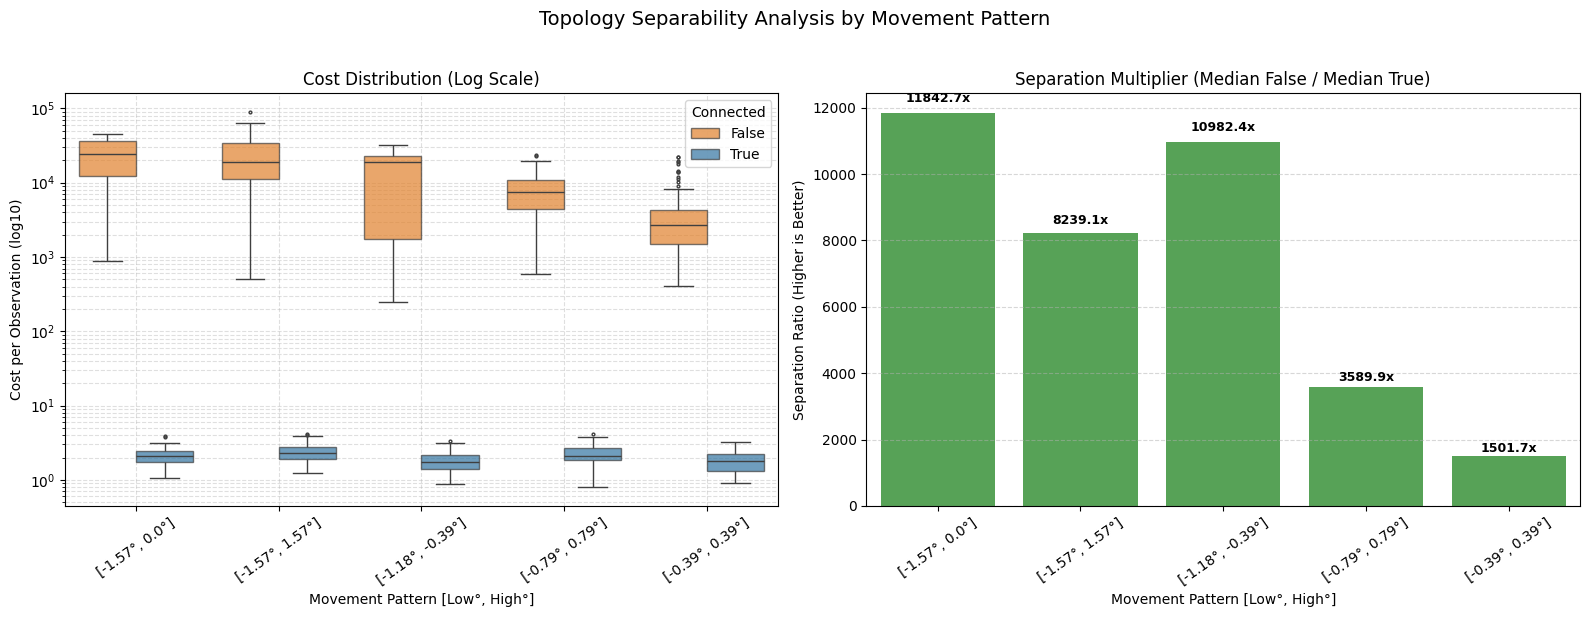

In [19]:
df = pd.read_csv("topo_results/results_topology_discovery_4.csv")

# Filter out non-finite costs
df = df[np.isfinite(df["cost_per_obs"])].copy()

# 2. Format and sort movement patterns
df["movement_pattern"] = (
    "[" + df["movement_low"].round(2).astype(str) + "°, " + 
    df["movement_high"].round(2).astype(str) + "°]"
)

pattern_order = (
    df[["movement_low", "movement_high", "movement_pattern"]]
    .drop_duplicates()
    .sort_values(by=["movement_low", "movement_high"])["movement_pattern"]
    .tolist()
)

# 3. Calculate Separability Metrics per Movement Pattern
metrics_list = []

for pattern, group in df.groupby("movement_pattern"):
    true_costs = group[group["connected"] == True]["cost_per_obs"]
    false_costs = group[group["connected"] == False]["cost_per_obs"]
    
    if true_costs.empty or false_costs.empty:
        continue

    # Metric A: Absolute Margin Gap (Min False - Max True)
    # Positive value = Perfect separation gap
    min_false = false_costs.min()
    max_true = true_costs.max()
    margin_gap = min_false - max_true

    # Metric B: Median Separation Ratio (False Median / True Median)
    sep_ratio = false_costs.median() / true_costs.median() if true_costs.median() > 0 else np.nan

    # Metric C: Percent Overlap (% of False costs <= 95th percentile of True costs)
    true_p95 = np.percentile(true_costs, 95)
    overlap_pct = (false_costs <= true_p95).mean() * 100.0

    metrics_list.append({
        "movement_pattern": pattern,
        "margin_gap": margin_gap,
        "sep_ratio": sep_ratio,
        "overlap_pct": overlap_pct
    })

metrics_df = pd.DataFrame(metrics_list)

# 4. Plotting: Log-Scale Boxplot (Raw View) + Separation Metrics Panel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

palette = {True: "#1f77b4", False: "#ff7f0e"}

# Panel 1: Log-Scale Boxplot / Strip Plot to inspect separation visually
sns.boxplot(
    data=df,
    x="movement_pattern",
    y="cost_per_obs",
    hue="connected",
    order=pattern_order,
    palette=palette,
    ax=ax1,
    fliersize=2,
    boxprops=dict(alpha=0.7)
)
ax1.set_yscale("log")  # Log scale resolves the dynamic range issue
ax1.set_title("Cost Distribution (Log Scale)", fontsize=12)
ax1.set_xlabel("Movement Pattern [Low°, High°]", fontsize=10)
ax1.set_ylabel("Cost per Observation (log10)", fontsize=10)
ax1.grid(True, which="both", linestyle="--", alpha=0.4)
ax1.tick_params(axis='x', rotation=35)
ax1.legend(title="Connected", loc="upper right")

# Panel 2: Separation Ratio Multiplier (Bar Plot)
sns.barplot(
    data=metrics_df,
    x="movement_pattern",
    y="sep_ratio",
    order=pattern_order,
    color="#2ca02c",
    alpha=0.85,
    ax=ax2
)

# Annotate values on top of the ratio bars
for bar in ax2.patches:
    height = bar.get_height()
    if np.isfinite(height) and height > 0:
        ax2.text(
            bar.get_x() + bar.get_width() / 2.0,
            height * 1.02,
            f"{height:.1f}x",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

ax2.set_title("Separation Multiplier (Median False / Median True)", fontsize=12)
ax2.set_xlabel("Movement Pattern [Low°, High°]", fontsize=10)
ax2.set_ylabel("Separation Ratio (Higher is Better)", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.tick_params(axis='x', rotation=35)

plt.suptitle("Topology Separability Analysis by Movement Pattern", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("topo_results/exp4/topology_separability_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# 1. Load data & filter valid observations
df = pd.read_csv("topo_results/results_topology_discovery_4.csv")
df = df[np.isfinite(df["cost_per_obs"])].copy()

# 2. Format and sort movement patterns
df["movement_pattern"] = (
    "[" + df["movement_low"].round(2).astype(str) + "°, " + 
    df["movement_high"].round(2).astype(str) + "°]"
)

# Optional: Order patterns by spatial coverage/range (e.g., Static -> Small Arc -> Full Sweep)
pattern_order = sorted(df["movement_pattern"].unique())
df["movement_pattern"] = pd.Categorical(
    df["movement_pattern"], categories=pattern_order, ordered=True
)

# 2. Compute Class Separation Multipliers
grouped = (
    df.groupby(["movement_pattern", "connected"])["cost_per_obs"]
    .median()
    .unstack(level="connected")
)
grouped["separation_multiplier"] = (
    grouped[False] / grouped[True]
)  # False / True ratio
piv_ordered = grouped.reindex(pattern_order).reset_index()

# 3. Create Subplots (Left: Log Cost Distributions, Right: Separation Ratio)
fig, axes = plt.subplots(
    1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.8, 1]}
)

# Subplot 1: Boxplot + Strip Plot of Costs per Class
sns.boxplot(
    data=df,
    x="movement_pattern",
    y="cost_per_obs",
    hue="connected",
    palette={True: "#2ecc71", False: "#e74c3c"},
    showfliers=False,
    boxprops=dict(alpha=0.7),
    ax=axes[0],
)
sns.stripplot(
    data=df,
    x="movement_pattern",
    y="cost_per_obs",
    hue="connected",
    dodge=True,
    alpha=0.3,
    size=3,
    palette={True: "#2ecc71", False: "#e74c3c"},
    ax=axes[0],
    legend=False,
)

axes[0].set_yscale("log")
axes[0].set_title(
    "Cost Distribution per Movement Pattern", fontsize=11, pad=10
)
axes[0].set_xlabel("Movement Pattern", fontsize=10)
axes[0].set_ylabel("Cost per Observation (Log Scale)", fontsize=10)
axes[0].grid(True, which="both", linestyle="--", alpha=0.4)

# Format Legend
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles[:2],
    ["Non-Connected (False)", "Connected (True)"],
    title="Class",
    loc="upper left",
)

# Subplot 2: Separation Multiplier Bar Chart
bars = axes[1].bar(
    piv_ordered["movement_pattern"],
    piv_ordered["separation_multiplier"],
    color="#3498db",
    edgecolor="black",
    linewidth=0.8,
    width=0.55,
)

axes[1].set_title("Class Separation Multiplier", fontsize=11, pad=10)
axes[1].set_xlabel("Movement Pattern", fontsize=10)
axes[1].set_ylabel("Median(False) / Median(True)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.4, axis="y")
axes[1].tick_params(axis="x", rotation=15)

# Value Annotations
for bar in bars:
  yval = bar.get_height()
  axes[1].annotate(
      f"{yval:.0f}x",
      (bar.get_x() + bar.get_width() / 2, yval),
      xytext=(0, 5),
      textcoords="offset points",
      ha="center",
      fontsize=9,
      weight="bold",
  )

plt.tight_layout()
plt.savefig(
    "topo_results/figs/exp4/movement_pattern_analysis.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close(fig)

In [19]:
# 1. Load data & filter valid observations
df = pd.read_csv("topo_results/results_topology_discovery_4.csv")
df = df[np.isfinite(df["cost_per_obs"])].copy()

# 2. Format and sort movement patterns
# df["movement_pattern"] = (
#     "["
#     + df["movement_low"].round(2).astype(str)
#     + "°, "
#     + df["movement_high"].round(2).astype(str)
#     + "°]"
# )

pattern_order = sorted(df["movement_name"].unique())
df["movement_name"] = pd.Categorical(
    df["movement_name"], categories=pattern_order, ordered=True
)

# 3. Plotting Configuration
threshold = 5.0  # Cost threshold boundary separating classes
palette = {True: "#1f77b4", False: "#ff7f0e"}  # Connected vs Non-connected

# 4. Create Single Figure
fig, ax = plt.subplots(figsize=(max(11, len(pattern_order) * 1.5), 6))

# Jittered strip plot on log-scale cost with class separation per pattern
sns.stripplot(
    data=df,
    x="movement_name",
    y="cost_per_obs",
    hue="connected",
    dodge=True,
    palette=palette,
    ax=ax,
    jitter=0.25,
    alpha=0.6,
    size=4,
)

ax.set_yscale("log")
ax.grid(True, which="both", linestyle="--", alpha=0.3)

# Threshold decision boundary line
ax.axhline(threshold, color="red", linestyle="--", linewidth=1.2)

# Axis labels and title formatting
ax.set_title(
    f"Cost Separation Distribution — Movement Patterns (Threshold = {threshold})",
    fontsize=12,
    pad=15,
)
ax.set_xlabel("Movement Pattern", fontsize=12)
ax.set_ylabel("Cost per Observation (Log Scale)", fontsize=12)
ax.tick_params(axis="x", rotation=15)

# Update legend labels to match class naming
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["Connected (True)", "Non-Connected (False)"],
    title="Class",
    loc="upper left", bbox_to_anchor=(1.02, 1)
)

# 5. Compute & Annotate Accuracy + FPR per Movement Pattern
y_max = df["cost_per_obs"].max()
y_annot = y_max * 1.8  # Positioning text box above high points in log space

for idx, pattern in enumerate(pattern_order):
  sub = df[df["movement_name"] == pattern]

  if sub.empty:
    continue

  actual_conn = sub["connected"]
  actual_non_conn = ~sub["connected"]

  pred_non_conn = sub["cost_per_obs"] >= threshold
  pred_conn = sub["cost_per_obs"] < threshold

  print(pattern)
  print(sub[pred_conn & actual_non_conn])

  TN = np.sum(pred_non_conn & actual_non_conn)
  TP = np.sum(pred_conn & actual_conn)
  FN = np.sum(pred_non_conn & actual_conn)
  FP = np.sum(pred_conn & actual_non_conn)

  total = len(sub)
  accuracy = (TP + TN) / total * 100 if total > 0 else 0.0

  actual_non_connected_count = FP + TN
  fpr = (
      FP / actual_non_connected_count * 100
      if actual_non_connected_count > 0
      else 0.0
  )

  # Text box annotation per movement pattern category
  ax.text(
      idx,
      y_annot,
      f"Acc: {accuracy:.1f}%\nFPR: {fpr:.1f}%",
      ha="center",
      va="bottom",
      fontsize=12,
      bbox=dict(
          boxstyle="round,pad=0.3",
          facecolor="white",
          alpha=0.85,
          edgecolor="lightgray",
      ),
  )

# Add upper limit buffer so annotations aren't clipped by the top border
ax.set_ylim(top=y_max * 10)

plt.tight_layout()
plt.savefig(
    "topo_results/figs/exp4/movement_pattern_single_plot_child.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close(fig)

-15 to 15 deg
Empty DataFrame
Columns: [sigma_pos, sigma_theta, sigma_encoder, k, connected, limb_id, child_id, cost_per_obs, cov_trace, cj_x, cj_y, cj_theta, movement_name]
Index: []
-90 to 0 deg
Empty DataFrame
Columns: [sigma_pos, sigma_theta, sigma_encoder, k, connected, limb_id, child_id, cost_per_obs, cov_trace, cj_x, cj_y, cj_theta, movement_name]
Index: []
-90 to 90 deg
Empty DataFrame
Columns: [sigma_pos, sigma_theta, sigma_encoder, k, connected, limb_id, child_id, cost_per_obs, cov_trace, cj_x, cj_y, cj_theta, movement_name]
Index: []
Child only
     sigma_pos  sigma_theta  sigma_encoder   k  connected  limb_id  child_id  \
422      0.001       0.0017         0.0009  15      False        0         2   
423      0.001       0.0017         0.0009  15      False        0         4   
424      0.001       0.0017         0.0009  15      False        2         0   
426      0.001       0.0017         0.0009  15      False        2         4   
427      0.001       0.0017         0.

**Calibration**

Experiment 1: how calibration accuracy varies with range and encoder noise

In [28]:
df = pd.read_csv("calib_results/results_calibration_1_lm.csv")

# 2. Compute Euclidean Distance Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Clean out non-finite values if any exist
df = df[np.isfinite(df["euclidean_error"])]

# Extract unique window sizes to iterate over
window_sizes = sorted(df["window_size"].unique())

# 3. Generate a plot for each window_size
for ws, df_ws in df.groupby("window_size"):

  # Pivot table for Mean Euclidean Error (determines cell background colors)
  pivot_mean = df_ws.pivot_table(
      index="sigma_encoder",
      columns="sigma_range",
      values="euclidean_error",
      aggfunc="mean",
  ).sort_index(ascending=False)

  # Pivot table for Standard Deviation
  pivot_std = df_ws.pivot_table(
      index="sigma_encoder",
      columns="sigma_range",
      values="euclidean_error",
      aggfunc="std",
  ).sort_index(ascending=False)

  # Create string annotation matrix with mean and (±std)
  annot_matrix = np.vectorize(lambda m, s: f"{m:.4f}\n(±{s:.4f})")(
      pivot_mean.values, pivot_std.values
  )

  # Plot Setup
  fig, ax = plt.subplots(figsize=(8, 6))

  # Seaborn Heatmap for 2D Grid Visualization
  sns.heatmap(
      pivot_mean,
      annot=annot_matrix,  # Pass custom string matrix
      fmt="",  # Set to empty string to prevent Seaborn numeric re-formatting
      cbar_kws={"label": "Mean Euclidean Error"},
      ax=ax,
      cmap="YlOrRd",
      linewidths=0.5,
      linecolor="gray",
  )

  # Axis Labels & Titles
  ax.set_title(
      f"Euclidean Error Grid — window_size = {ws}", fontsize=15, pad=12
  )
  ax.set_xlabel("sigma_range", fontsize=12)
  ax.set_ylabel("sigma_encoder", fontsize=12)

  plt.tight_layout()
  plt.savefig(
      f"calib_results/figs/exp1/euclidean_error_grid_ws_lm_{ws}.png",
      dpi=150,
      bbox_inches="tight",
  )
  plt.close(fig)  # Close figure to free up RAM

In [3]:
df = pd.read_csv("calib_results/results_calibration_1.csv")

# 2. Compute Euclidean Distance Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Clean out non-finite values if any exist
df = df[np.isfinite(df["euclidean_error"])]

encoder_vals = sorted(df["sigma_encoder"].unique())  # Rows (y-axis)
range_vals = sorted(df["sigma_range"].unique())      # Columns (x-axis)

for ws, df_ws in df.groupby("window_size"):
    
    fig, axes = plt.subplots(
        len(encoder_vals), 
        len(range_vals),
        figsize=(3.5 * len(range_vals), 3.0 * len(encoder_vals)),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_2d(axes)

    for r, se in enumerate(reversed(encoder_vals)):  # Higher encoder on top
        for c, sr in enumerate(range_vals):
            ax = axes[r, c]
            
            sub = df_ws[(df_ws["sigma_encoder"] == se) & (df_ws["sigma_range"] == sr)]

            if sub.empty:
                ax.set_visible(False)
                continue

            sns.histplot(
                data=sub, 
                x="euclidean_error", 
                bins=30, 
                ax=ax,
                color="#1f77b4",
                element="step", 
                fill=True, 
                alpha=0.5
            )

            if r == 0:
                ax.set_title(f"σ_range = {sr}", fontsize=10)
            if c == 0:
                ax.set_ylabel(f"σ_enc = {se}\nCount", fontsize=9)
            if r == len(encoder_vals) - 1:
                ax.set_xlabel("Euclidean Error", fontsize=9)

    fig.suptitle(f"Euclidean Error Distribution Grid — window_size = {ws}", y=1.02)
    plt.tight_layout()
    plt.savefig(f"calib_results/figs/exp1/error_hist_grid_ws_{ws}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

In [11]:
df = pd.read_csv("calib_results/results_calibration_1.csv")

# 2. Compute Euclidean Distance Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Filter invalid values
df = df[np.isfinite(df["euclidean_error"])]

# Unique parameter values
range_vals = sorted(df["sigma_range"].unique())     # Grid X-axis (columns)
encoder_vals = sorted(df["sigma_encoder"].unique()) # Grid Y-axis (rows)
window_sizes = sorted(df["window_size"].unique())

# 3. Generate Grid Plot for each window_size
for ws, df_ws in df.groupby("window_size"):

    fig, axes = plt.subplots(
        len(encoder_vals),
        len(range_vals),
        figsize=(3.5 * len(range_vals), 3.0 * len(encoder_vals)),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_2d(axes)

    # Plot higher encoder values at top of grid
    for r, se in enumerate(reversed(encoder_vals)):
        for c, sr in enumerate(range_vals):
            ax = axes[r, c]

            # Filter raw dataset for this grid cell
            sub = df_ws[
                (df_ws["sigma_encoder"] == se) & 
                (df_ws["sigma_range"] == sr)
            ]

            if sub.empty:
                ax.set_visible(False)
                continue

            # Seaborn barplot automatically calculates Mean + Error Bars
            # errorbar="sd" plots Standard Deviation. 
            # Set errorbar="ci" (or 95) for 95% Confidence Interval.
            sns.barplot(
                data=sub,
                x="calib_id",
                y="euclidean_error",
                ax=ax,
                color="#1f77b4",
                alpha=0.85,
                errorbar="sd",       # Options: "sd" (Standard Dev) or ("ci", 95)
                capsize=0.15,        # Adds horizontal caps to the error bars
                err_kws={'linewidth': 1.2, 'color': 'black'}
            )

            # Titles & Axis Labels
            if r == 0:
                ax.set_title(f"σ_range = {sr}", fontsize=10)
            if c == 0:
                ax.set_ylabel(f"σ_enc = {se}\nMean Error", fontsize=9)
            else:
                ax.set_ylabel("")

            if r == len(encoder_vals) - 1:
                ax.set_xlabel("Calibration ID", fontsize=9)
            else:
                ax.set_xlabel("")

            # Rotate ID tick labels for readability
            ax.tick_params(axis='x', rotation=45)

    fig.suptitle(f"Mean Euclidean Error with Error Bars (±1 SD) — window_size = {ws}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"calib_results/figs/exp1/error_by_id_grid_ws_{ws}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

Experiment 2: number of limbs and solver iterations needed. calibration accuracy

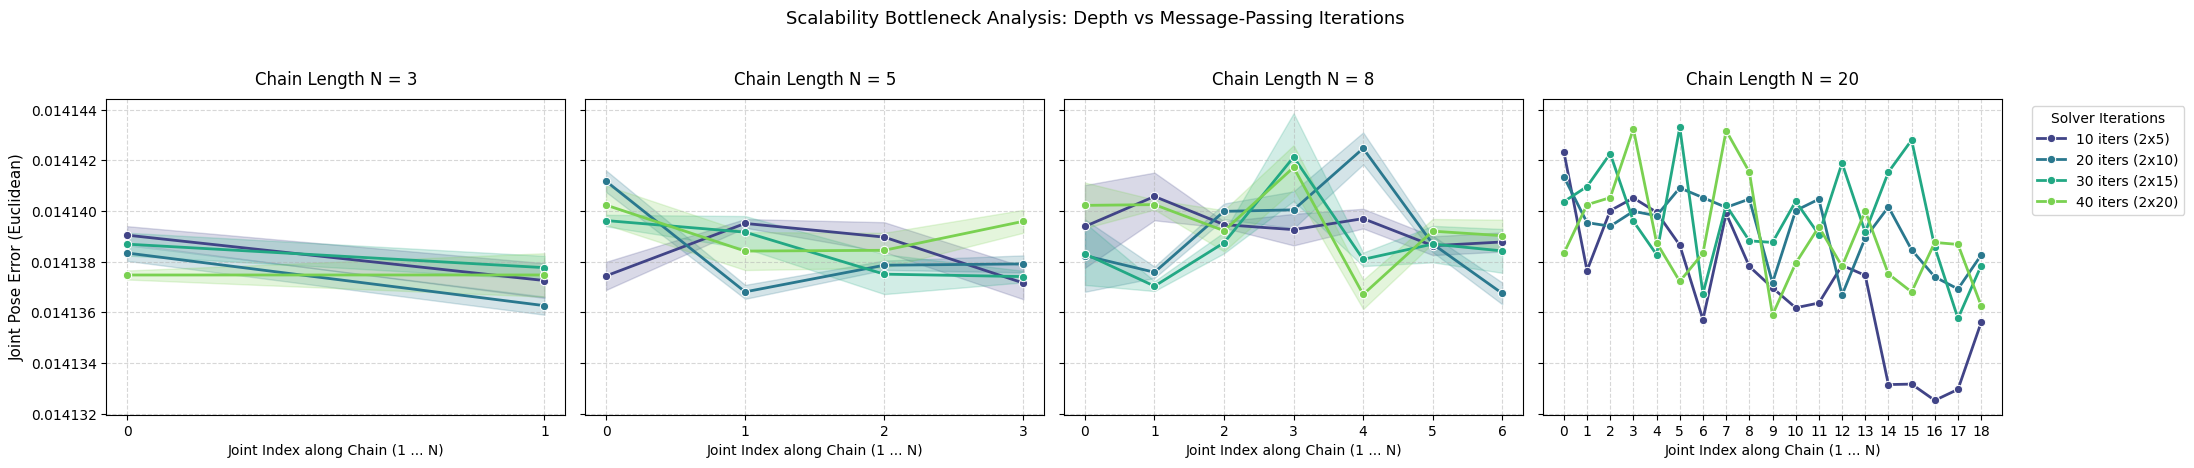

In [6]:
import glob

# 1. Define list of dataset files or load via glob pattern
# Example list of files: ["dataset_N3.csv", "dataset_N6.csv", "dataset_N12.csv"]
dataset_files = glob.glob("calib_results/results_calibration_2_*.csv")

dataframes = []

for file in dataset_files:
    temp_df = pd.read_csv(file)
    
    # Extract chain length N from file name or a dedicated column if available
    # Assuming 'n_limbs' column exists; if not, parse it or assign explicitly
    if "n_limbs" not in temp_df.columns:
        # Fallback: estimate N as max calib_id + 1 for this file
        temp_df["n_limbs"] = temp_df["calib_id"].max() + 1
        
    dataframes.append(temp_df)

# Combine into a single unified DataFrame
df = pd.concat(dataframes, ignore_index=True)

# 2. Compute Euclidean Joint Position Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Filter out non-finite values
df = df[np.isfinite(df["euclidean_error"])].copy()

# 3. Compute Total Iterations (I = n_outer * n_inner)
# Creates a clean label for legend sorting
df["total_iterations"] = df["n_outer"] * df["n_inner"]
df["iteration_label"] = df["total_iterations"].astype(str) + " iters (" + \
                        df["n_outer"].astype(str) + "x" + df["n_inner"].astype(str) + ")"

# Sort unique N and iterations for consistent plotting
chain_lengths = sorted(df["n_limbs"].unique())
iter_orders = (
    df[["total_iterations", "iteration_label"]]
    .drop_duplicates()
    .sort_values("total_iterations")["iteration_label"]
    .tolist()
)

# 4. Setup Faceted Subplot Grid (1 row, Facet by Chain Length N)
fig, axes = plt.subplots(
    nrows=1, 
    ncols=len(chain_lengths), 
    figsize=(5.5 * len(chain_lengths), 4.5), 
    sharey=True
)

if len(chain_lengths) == 1:
    axes = [axes]

palette = sns.color_palette("viridis", n_colors=len(iter_orders))

# 5. Plot Line Series per Chain Length (N)
for idx, n_val in enumerate(chain_lengths):
    ax = axes[idx]
    sub_df = df[df["n_limbs"] == n_val]
    
    # Lineplot automatically averages over repeated runs and adds shaded CIs (±1 SD)
    sns.lineplot(
        data=sub_df,
        x="calib_id",
        y="euclidean_error",
        hue="iteration_label",
        hue_order=iter_orders,
        marker="o",
        linewidth=2,
        palette=palette,
        errorbar="sd",
        ax=ax
    )
    
    # Formatting
    ax.set_title(f"Chain Length N = {n_val}", fontsize=12, pad=10)
    ax.set_xlabel("Joint Index along Chain (1 ... N)", fontsize=10)
    ax.set_xticks(sorted(sub_df["calib_id"].unique()))
    ax.grid(True, linestyle="--", alpha=0.5)
    
    if idx == 0:
        ax.set_ylabel("Joint Pose Error (Euclidean)", fontsize=11)
    else:
        ax.set_ylabel("")
        
    # Manage legends across subplots (only keep on rightmost plot)
    if idx == len(chain_lengths) - 1:
        ax.legend(title="Solver Iterations", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

fig.suptitle("Scalability Bottleneck Analysis: Depth vs Message-Passing Iterations", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig("calib_results/figs/exp2/scalability_chain_length_vs_iterations.png", dpi=150, bbox_inches="tight")
plt.show()

Experiment 3: how calibration accuracy varies with movement type

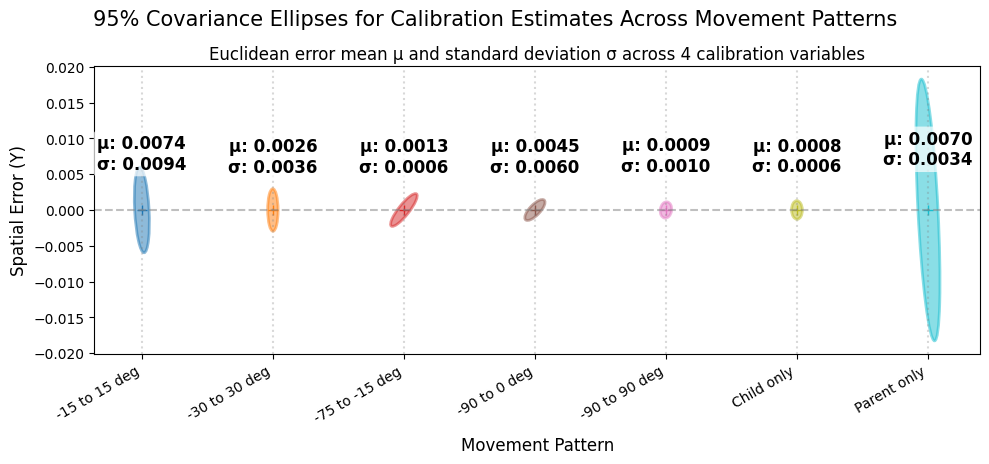

In [33]:
from matplotlib.patches import Ellipse

def get_ellipse_params(cov, n_std=2.447):  # 2.447 for 95% CI
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width = 2 * n_std * np.sqrt(np.maximum(0, eigenvalues[0]))
    height = 2 * n_std * np.sqrt(np.maximum(0, eigenvalues[1]))
    return width, height, angle, eigenvalues

# 1. Load dataset
df = pd.read_csv("calib_results/results_calibration_3_15.csv")

# for parent only and child only patterns remove off calibration ids becaue these do not follow the specific pattern
target_patterns = ['Child only', 'Parent only']
remove_mask = df['movement_name'].isin(target_patterns) & (df['calib_id'] % 2 != 0)
df = df[~remove_mask]

# 2. Compute Euclidean Error & Labels
df["euclidean_error"] = np.sqrt((df["est_cj_x"] - df["cj_x"])**2 + (df["est_cj_y"] - df["cj_y"])**2)
df = df[np.isfinite(df["euclidean_error"])].copy()

pattern_order = sorted(df["movement_name"].unique())
df["movement_name"] = pd.Categorical(
    df["movement_name"], categories=pattern_order, ordered=True
)
pattern_order = ['-15 to 15 deg', '-30 to 30 deg', '-75 to -15 deg', '-90 to 0 deg', '-90 to 90 deg', 'Child only', 'Parent only']

stats = df.groupby("movement_name", observed=False)["euclidean_error"].agg(["mean", "std"])

avg_covs = df.groupby("movement_name")[["cov_00", "cov_01", "cov_10", "cov_11"]].mean().reindex(pattern_order)

# 3. Calculate spacing dynamically
max_dim = 0
for pattern in pattern_order:
    row = avg_covs.loc[pattern]
    cov = np.array([[row["cov_00"], row["cov_01"]], [row["cov_10"], row["cov_11"]]])
    w, h, _, _ = get_ellipse_params(cov)
    max_dim = max(max_dim, w, h)

# --- ADJUST SPACING HERE ---
spacing_multiplier = 0.5  # Lower value = closer together & visually LARGER ellipses
spacing = max_dim * spacing_multiplier
x_coords = np.arange(len(pattern_order)) * spacing

# 4. Plot Setup (Increased height to make ellipses larger)
fig, ax = plt.subplots(figsize=(10, 5))
patterns = avg_covs.index
colors = plt.cm.tab10(np.linspace(0, 1, len(patterns)))

for i, pattern in enumerate(patterns):
    row = avg_covs.loc[pattern]
    cov = np.array([[row["cov_00"], row["cov_01"]], [row["cov_10"], row["cov_11"]]])
    width, height, angle, (lam1, lam2) = get_ellipse_params(cov)

    ellipse = Ellipse(
        xy=(x_coords[i], 0), width=width, height=height, angle=angle,
        edgecolor=colors[i], facecolor=colors[i], alpha=0.5, lw=2,
        label=f"{pattern} (Ratio: {np.sqrt(lam1/lam2):.2f})"
    )
    ax.add_patch(ellipse)
    m_val = stats.loc[pattern, "mean"]
    s_val = stats.loc[pattern, "std"]

    ax.text(
        x_coords[i], 
        (0.75*height) + (max_dim * 0.1),  # Dynamic offset placing text right above the ellipse apex
        f"μ: {m_val:.4f}\nσ: {s_val:.4f}", 
        ha='center', 
        va='bottom', 
        fontsize=12, 
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
    )
    ax.plot(x_coords[i], 0, '+', color=colors[i], markersize=7)

# Styling & Axes
ax.set_xticks(x_coords)
ax.set_xticklabels(patterns, rotation=30, ha="right")
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

for xc in x_coords:
    ax.axvline(xc, color='gray', linestyle=':', alpha=0.3)

ax.set_aspect('equal')
fig.suptitle("95% Covariance Ellipses for Calibration Estimates Across Movement Patterns", fontsize=15, y=0.9)
ax.set_title("Euclidean error mean μ and standard deviation σ across 4 calibration variables", fontsize=12, pad=5)
ax.set_xlabel("Movement Pattern", fontsize=12, labelpad=8)
ax.set_ylabel("Spatial Error (Y)", fontsize=12)
# ax.legend(title="Movement Pattern (Major/Minor Ratio)", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.autoscale()

plt.tight_layout()
plt.savefig("calib_results/figs/exp3/uncertainty_ellipses_by_pattern_20.png", dpi=150, bbox_inches="tight")
plt.show()